# JLM and JLMB optical-potential benchmarks

This notebook converts the old `examples/example_jlm.py` script into an executable,
narrative example. It walks through four benchmark calculations:

1. $^{40}$Ca + p at 30 MeV
2. $^{208}$Pb + n at 14 MeV
3. a neutron-vs-proton Lane comparison on $^{208}$Pb at 14 MeV
4. a tabulated self-energy round-trip against the analytical model


In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np

from jitr.folding import TabulatedNMSelfEnergy, TwoParameterFermiDensity
from jitr.folding.jlm import JLMPotential, JLMSelfEnergy, make_jlmb_parameters


In [2]:
def ca40_density():
    return TwoParameterFermiDensity(R=3.51, a=0.563, N=20)


def pb208_densities():
    rho_n = TwoParameterFermiDensity(R=6.7, a=0.55, N=126)
    rho_p = TwoParameterFermiDensity(R=6.654, a=0.547, N=82)
    return rho_n, rho_p


def plot_potential(R, V, W, title, JV, JW):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(R, V, 'b-', lw=2)
    ax1.axhline(0, color='k', lw=0.5)
    ax1.set_xlabel('$R$ (fm)')
    ax1.set_ylabel('$V$ (MeV)')
    ax1.set_title(f"{title} -- $J_V/A$ = {JV:.0f} MeV fm$^3$")
    ax1.grid(alpha=0.3)

    ax2.plot(R, W, 'r-', lw=2)
    ax2.axhline(0, color='k', lw=0.5)
    ax2.set_xlabel('$R$ (fm)')
    ax2.set_ylabel('$W$ (MeV)')
    ax2.set_title(f"Imaginary -- $J_W/A$ = {JW:.0f} MeV fm$^3$")
    ax2.grid(alpha=0.3)
    fig.tight_layout()
    return fig


## $^{40}$Ca + p at 30 MeV

This light, nearly symmetric system is a convenient first benchmark for the folded
microscopic potential.


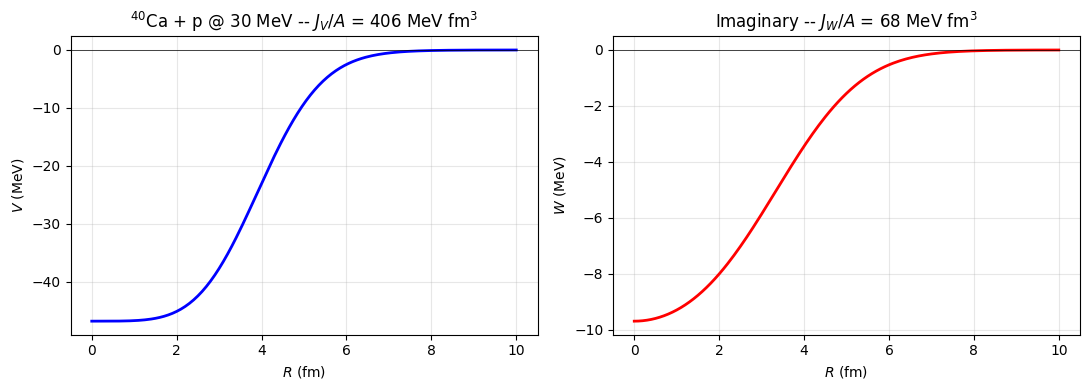

J_V / A =  405.5 MeV*fm^3
J_W / A =   68.1 MeV*fm^3


In [3]:
rho_n = ca40_density()
rho_p = ca40_density()
se = JLMSelfEnergy('p')
pot = JLMPotential(rho_n, rho_p, se, parameters=make_jlmb_parameters(E=30.0))

R = np.linspace(0.0, 10.0, 201)
V, W = pot.compute(R, E=30.0, projectile='p', Z=20, A=40)
JV, JW = pot.volume_integrals(E=30.0, projectile='p', A_target=40, Z=20, A=40)

plot_potential(R, V, W, r'$^{40}$Ca + p @ 30 MeV', JV, JW)
plt.show()
print(f'J_V / A = {JV:6.1f} MeV*fm^3')
print(f'J_W / A = {JW:6.1f} MeV*fm^3')


## $^{208}$Pb + n at 14 MeV

The neutron-rich heavy target makes the density dependence and isovector trends more
visible.


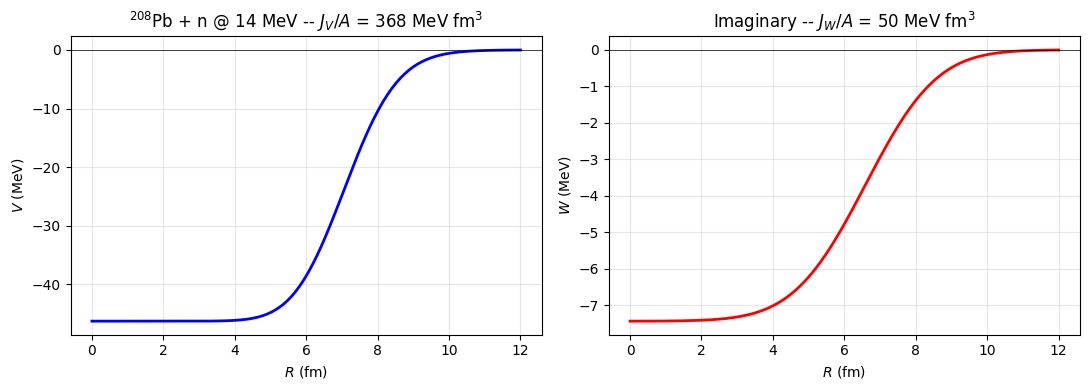

J_V / A =  367.7 MeV*fm^3
J_W / A =   50.3 MeV*fm^3


In [4]:
rho_n, rho_p = pb208_densities()
se = JLMSelfEnergy('n')
pot = JLMPotential(rho_n, rho_p, se, parameters=make_jlmb_parameters(E=14.0))

R = np.linspace(0.0, 12.0, 201)
V, W = pot.compute(R, E=14.0, projectile='n')
JV, JW = pot.volume_integrals(E=14.0, projectile='n', A_target=208)

plot_potential(R, V, W, r'$^{208}$Pb + n @ 14 MeV', JV, JW)
plt.show()
print(f'J_V / A = {JV:6.1f} MeV*fm^3')
print(f'J_W / A = {JW:6.1f} MeV*fm^3')


## Lane comparison on $^{208}$Pb

Disabling the Coulomb shift isolates the isovector part of the folded self-energy.


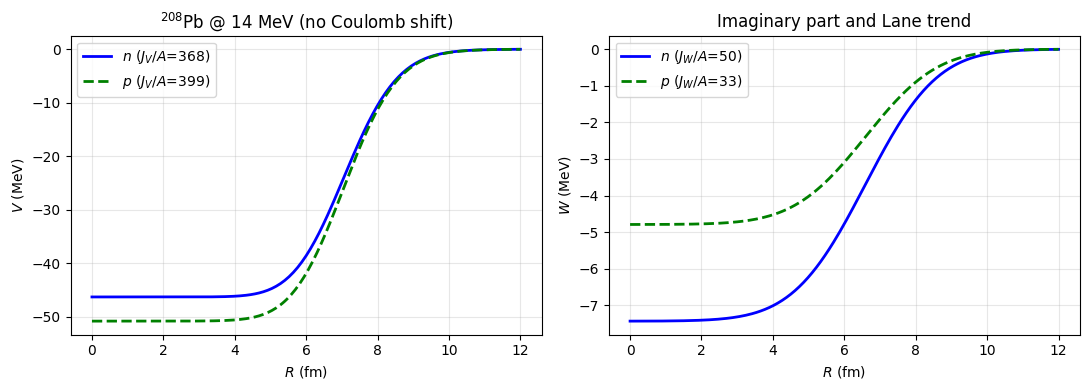

Lane shift (J_V,p - J_V,n) =  31.7 MeV*fm^3 per A


In [5]:
rho_n, rho_p = pb208_densities()
params = make_jlmb_parameters(E=14.0, apply_coulomb_shift=False)
pot_n = JLMPotential(rho_n, rho_p, JLMSelfEnergy('n'), parameters=params)
pot_p = JLMPotential(rho_n, rho_p, JLMSelfEnergy('p'), parameters=params)

R = np.linspace(0.0, 12.0, 201)
Vn, Wn = pot_n.compute(R, E=14.0, projectile='n')
Vp, Wp = pot_p.compute(R, E=14.0, projectile='p')
JVn, JWn = pot_n.volume_integrals(14.0, 'n', 208)
JVp, JWp = pot_p.volume_integrals(14.0, 'p', 208)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(R, Vn, 'b-', lw=2, label=rf'$n$ ($J_V/A$={JVn:.0f})')
ax1.plot(R, Vp, 'g--', lw=2, label=rf'$p$ ($J_V/A$={JVp:.0f})')
ax1.set_xlabel('$R$ (fm)')
ax1.set_ylabel('$V$ (MeV)')
ax1.set_title(r'$^{208}$Pb @ 14 MeV (no Coulomb shift)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(R, Wn, 'b-', lw=2, label=rf'$n$ ($J_W/A$={JWn:.0f})')
ax2.plot(R, Wp, 'g--', lw=2, label=rf'$p$ ($J_W/A$={JWp:.0f})')
ax2.set_xlabel('$R$ (fm)')
ax2.set_ylabel('$W$ (MeV)')
ax2.set_title(r'Imaginary part and Lane trend')
ax2.legend()
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f'Lane shift (J_V,p - J_V,n) = {JVp - JVn:5.1f} MeV*fm^3 per A')


## Tabulated self-energy round-trip

The tabulated wrapper is the route you would use for published JLM/JLMB tables from
TALYS or RIPL-3.


In [6]:
se_analytic_n = JLMSelfEnergy('n')
se_tab_n = TabulatedNMSelfEnergy.from_analytical(se_analytic_n)

rho_n, rho_p = pb208_densities()
params = make_jlmb_parameters(E=14.0)
pot_analytic = JLMPotential(rho_n, rho_p, se_analytic_n, parameters=params)
pot_tab = JLMPotential(rho_n, rho_p, se_tab_n, parameters=params)

JVa, JWa = pot_analytic.volume_integrals(14.0, 'n', 208)
JVt, JWt = pot_tab.volume_integrals(14.0, 'n', 208)

print(f'analytical: J_V/A = {JVa:6.2f}, J_W/A = {JWa:6.2f}')
print(f'tabulated : J_V/A = {JVt:6.2f}, J_W/A = {JWt:6.2f}')
print(f'difference : dJ_V = {JVa - JVt:+6.3f}, dJ_W = {JWa - JWt:+6.3f}')

with tempfile.NamedTemporaryFile('w', suffix='.txt', delete=False) as fh:
    path = fh.name
se_tab_n.save_text_file(path)
se_tab_loaded = TabulatedNMSelfEnergy.from_text_file(path, projectile='n')
print(f'saved/loaded: {os.path.basename(path)} ({se_tab_loaded.E_grid.size} energies)')
os.unlink(path)


analytical: J_V/A = 367.75, J_W/A =  50.29
tabulated : J_V/A = 367.60, J_W/A =  50.23
difference : dJ_V = +0.151, dJ_W = +0.060
saved/loaded: tmpa8_52das.txt (60 energies)
